In [3]:
!pip install xgboost

In [4]:
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor

pd.set_option("display.max_columns", None)
print("🚀 Libraries Loaded!")

🚀 Libraries Loaded!


In [5]:
df = pd.read_csv("housing.csv")

df["total_bedrooms"] = df["total_bedrooms"].fillna(
    df["total_bedrooms"].median()
)

df["AveRooms"] = df["total_rooms"] / df["households"]
df["AveBedrms"] = df["total_bedrooms"] / df["households"]
df["AveOccup"] = df["population"] / df["households"]

df = df.rename(
    columns={
        "housing_median_age": "HouseAge",
        "median_income": "MedInc",
        "population": "Population",
        "median_house_value": "Gia_Nha",
    }
)

df_visual = df.copy()

df = pd.get_dummies(df, columns=["ocean_proximity"], drop_first=True)

feature_names = [
    "MedInc",
    "HouseAge",
    "AveRooms",
    "AveBedrms",
    "Population",
    "AveOccup",
    "latitude",
    "longitude",
]
ocean_cols = [col for col in df.columns if "ocean_proximity_" in col]
feature_names.extend(ocean_cols)

df.head(5)

,longitude,latitude,HouseAge,total_rooms,total_bedrooms,Population,households,MedInc,Gia_Nha,AveRooms,AveBedrms,AveOccup,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,6.984127,1.023810,2.555556,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,6.238137,0.971880,2.109842,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,8.288136,1.073446,2.802260,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,5.817352,1.073059,2.547945,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,6.281853,1.081081,2.181467,False,False,True,False


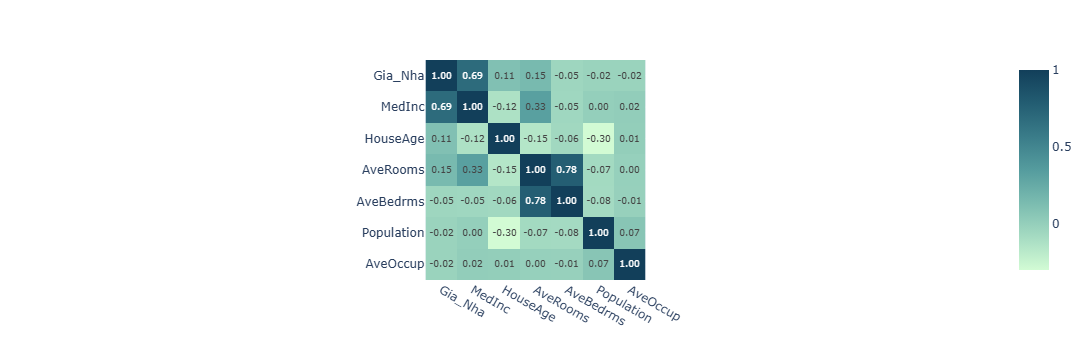

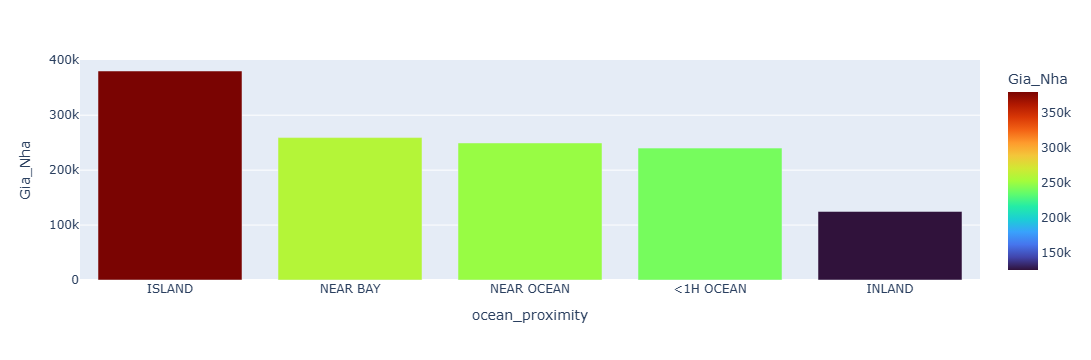

In [7]:
corr_cols = [
    "Gia_Nha",
    "MedInc",
    "HouseAge",
    "AveRooms",
    "AveBedrms",
    "Population",
    "AveOccup",
]
corr_matrix = df_visual[corr_cols].corr()

fig_corr = px.imshow(
    corr_matrix, text_auto=".2f", color_continuous_scale="Darkmint"
)
fig_corr.show()

ocean_price = (
    df_visual.groupby("ocean_proximity")["Gia_Nha"]
    .mean()
    .reset_index()
    .sort_values(by="Gia_Nha", ascending=False)
)
fig_bar = px.bar(
    ocean_price,
    x="ocean_proximity",
    y="Gia_Nha",
    color="Gia_Nha",
    color_continuous_scale="Turbo",
)
fig_bar.show()

In [9]:
X = df[feature_names]
y = df["Gia_Nha"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")

Train size: 16512 | Test size: 4128


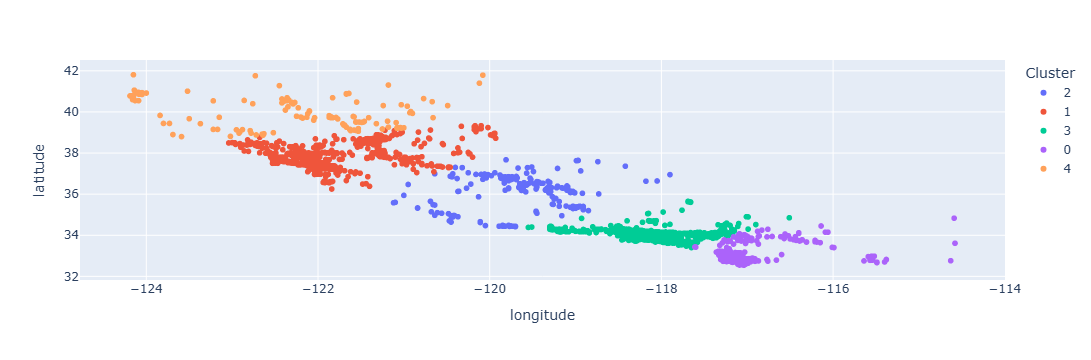

In [10]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans.fit(X_train[["latitude", "longitude"]])

df_cluster = df_visual.sample(3000, random_state=42).copy()
df_cluster["Cluster"] = kmeans.predict(
    df_cluster[["latitude", "longitude"]]
).astype(str)

fig_cluster = px.scatter(df_cluster, x="longitude", y="latitude", color="Cluster")
fig_cluster.show()

In [11]:
models = {
    "Linear Regression": LinearRegression(),
    "K-Nearest Neighbors": KNeighborsRegressor(n_neighbors=9),
    "Decision Tree": DecisionTreeRegressor(max_depth=10, random_state=42),
    "Random Forest": RandomForestRegressor(
        n_estimators=100, max_depth=12, random_state=42, n_jobs=-1
    ),
    "XGBoost Regressor": XGBRegressor(
        n_estimators=150, max_depth=6, learning_rate=0.1, random_state=42
    ),
}

experimental_results = []

for name, model in models.items():
    if name in ["Linear Regression", "K-Nearest Neighbors"]:
        model.fit(X_train_scaled, y_train)
        train_preds = model.predict(X_train_scaled)
        test_preds = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        train_preds = model.predict(X_train)
        test_preds = model.predict(X_test)

    r2_train = r2_score(y_train, train_preds)
    r2_test = r2_score(y_test, test_preds)
    rmse_test = np.sqrt(mean_squared_error(y_test, test_preds))
    mae_test = mean_absolute_error(y_test, test_preds)

    experimental_results.append(
        {
            "Model": name,
            "Train R²": round(r2_train, 4),
            "Test R²": round(r2_test, 4),
            "RMSE": round(rmse_test, 2),
            "MAE": round(mae_test, 2),
        }
    )

df_results = pd.DataFrame(experimental_results)
df_results = df_results.sort_values(by="Test R²", ascending=False).reset_index(
    drop=True
)
df_results

,Model,Train R²,Test R²,RMSE,MAE
0,XGBoost Regressor,0.9169,0.8384,46019.10,30091.77
1,Random Forest,0.9127,0.7955,51769.48,33916.83
2,Decision Tree,0.8405,0.7012,62574.79,40091.69
3,K-Nearest Neighbors,0.7719,0.6911,63621.18,42395.81
4,Linear Regression,0.6218,0.4961,81262.18,53879.75
